In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
sentiment_df = pd.read_csv("csv_files/fear_greed_index.csv")
trader_df = pd.read_csv("csv_files/historical_data.csv")

In [4]:
print("Trader Shape:", trader_df.shape)
print("Sentiment Shape:", sentiment_df.shape)

Trader Shape: (211224, 16)
Sentiment Shape: (2644, 4)


In [5]:
print("Trader columns:", trader_df.columns)
print("Sentiment columns:", sentiment_df.columns)

Trader columns: Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')
Sentiment columns: Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [6]:
print("Null values in trader_df:\n", trader_df.isnull().sum())
print("\nNull values in sentiment_df:\n", sentiment_df.isnull().sum())

Null values in trader_df:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Null values in sentiment_df:
 timestamp         0
value             0
classification    0
date              0
dtype: int64


In [7]:
print("\nDuplicate rows in trader_df:", trader_df.duplicated().sum())
print("Duplicate rows in sentiment_df:", sentiment_df.duplicated().sum())


Duplicate rows in trader_df: 0
Duplicate rows in sentiment_df: 0


In [8]:
trader_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [9]:
sentiment_df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


### Data Cleaning and Feature Engineering

In [10]:
sentiment_df["date"] = pd.to_datetime(sentiment_df["date"])
sentiment_df["value"] = pd.to_numeric(sentiment_df["value"], errors="coerce")
sentiment_df = sentiment_df.dropna(subset=["date", "value"])

trader_df["Timestamp IST"] = pd.to_datetime(trader_df["Timestamp IST"], dayfirst=True, errors="coerce")
trader_df = trader_df.dropna(subset=["Timestamp IST"])

trader_df["trade_date"] = trader_df["Timestamp IST"].dt.date
sentiment_df["trade_date"] = sentiment_df["date"].dt.date

print("Unique trader dates:", trader_df["trade_date"].nunique())
print("Unique sentiment dates:", sentiment_df["trade_date"].nunique())


Unique trader dates: 480
Unique sentiment dates: 2644


In [11]:
# Numeric cleaning + feature engineering
num_cols = ["Execution Price", "Size Tokens", "Size USD", "Closed PnL", "Fee"]
for col in num_cols:
    trader_df[col] = pd.to_numeric(trader_df[col], errors="coerce")

trader_df = trader_df.dropna(subset=["Size USD", "Closed PnL"])

trader_df["volume_usd"] = trader_df["Size USD"].abs()
trader_df["is_profit"] = trader_df["Closed PnL"] > 0
trader_df["abs_pnl"] = trader_df["Closed PnL"].abs()

trader_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,trade_date,volume_usd,is_profit,abs_pnl
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,7872.16,False,0.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,127.68,False,0.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1150.63,False,0.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1142.04,False,0.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,69.75,False,0.0


### Trades behavior 

In [12]:
daily_trader = trader_df.groupby("trade_date").agg(
    total_trades=("Trade ID", "count"),
    total_volume_usd=("volume_usd", "sum"),
    avg_trade_size=("volume_usd", "mean"),
    total_pnl=("Closed PnL", "sum"),
    avg_pnl=("Closed PnL", "mean"),
    win_rate=("is_profit", "mean"),
    total_fees=("Fee", "sum"),
).reset_index()

print("Daily trader shape:", daily_trader.shape)

Daily trader shape: (480, 8)


In [13]:
daily_trader.head()

,trade_date,total_trades,total_volume_usd,avg_trade_size,total_pnl,avg_pnl,win_rate,total_fees
0,2023-05-01,3,477.00,159.000000,0.000000,0.000000,0.000000,0.000000
1,2023-12-05,9,50005.83,5556.203333,0.000000,0.000000,0.000000,12.501455
2,2023-12-14,11,113203.35,10291.213636,-205.434737,-18.675885,0.363636,28.300831
3,2023-12-15,2,10609.95,5304.975000,-24.632034,-12.316017,0.000000,2.652489
4,2023-12-16,3,15348.77,5116.256667,0.000000,0.000000,0.000000,3.837189


In [14]:
merged_df = pd.merge(daily_trader, sentiment_df, on="trade_date", how="inner")

print("Merged Shape:", merged_df.shape)
merged_df.head()


Merged Shape: (479, 12)


,trade_date,total_trades,total_volume_usd,avg_trade_size,total_pnl,avg_pnl,win_rate,total_fees,timestamp,value,classification,date
0,2023-05-01,3,477.00,159.000000,0.000000,0.000000,0.000000,0.000000,1682919000,63,Greed,2023-05-01
1,2023-12-05,9,50005.83,5556.203333,0.000000,0.000000,0.000000,12.501455,1701754200,75,Extreme Greed,2023-12-05
2,2023-12-14,11,113203.35,10291.213636,-205.434737,-18.675885,0.363636,28.300831,1702531800,72,Greed,2023-12-14
3,2023-12-15,2,10609.95,5304.975000,-24.632034,-12.316017,0.000000,2.652489,1702618200,70,Greed,2023-12-15
4,2023-12-16,3,15348.77,5116.256667,0.000000,0.000000,0.000000,3.837189,1702704600,67,Greed,2023-12-16


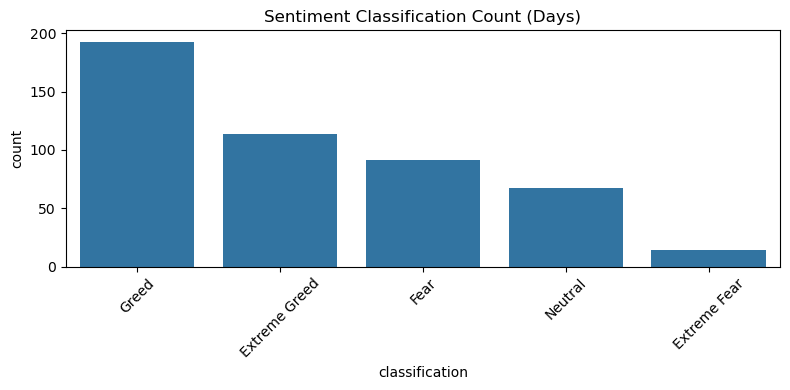

In [20]:
# Sentiment distribution (how many days in Fear/Greed etc.)
plt.figure(figsize=(8,4))
sns.countplot(data=merged_df, x="classification", order=merged_df["classification"].value_counts().index)
plt.title("Sentiment Classification Count (Days)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("outputs/sentiment_count.png")
plt.show()


In [15]:
corr_cols = ["value", "total_volume_usd", "total_trades", "total_pnl", "win_rate", "avg_trade_size"]
display(merged_df[corr_cols].corr())

,value,total_volume_usd,total_trades,total_pnl,win_rate,avg_trade_size
value,1.000000,-0.264371,-0.245241,-0.082642,0.152485,-0.051824
total_volume_usd,-0.264371,1.000000,0.720137,0.325759,0.048477,0.281838
total_trades,-0.245241,0.720137,1.000000,0.360552,0.095852,-0.047462
total_pnl,-0.082642,0.325759,0.360552,1.000000,0.170086,-0.015941
win_rate,0.152485,0.048477,0.095852,0.170086,1.000000,-0.040215
avg_trade_size,-0.051824,0.281838,-0.047462,-0.015941,-0.040215,1.000000


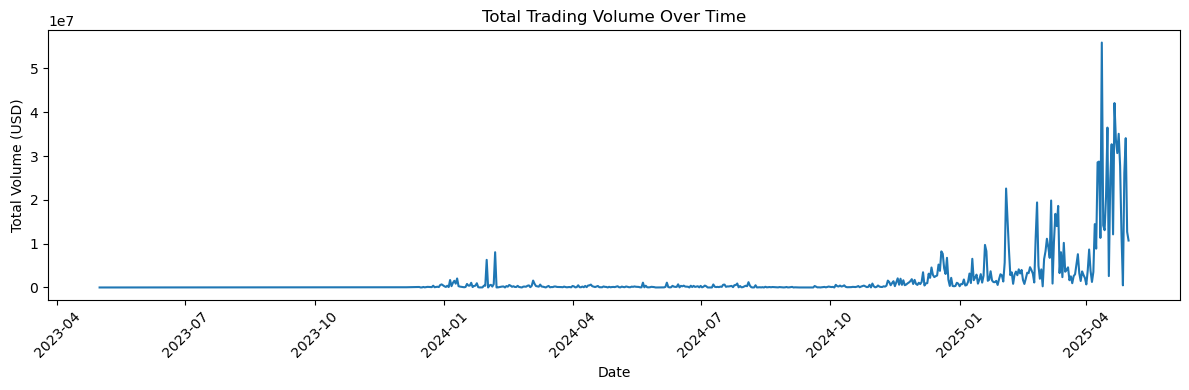

In [21]:
# Sort by date for time series plots
merged_df["trade_date"] = pd.to_datetime(merged_df["trade_date"])
merged_df = merged_df.sort_values("trade_date")

plt.figure(figsize=(12,4))
plt.plot(merged_df["trade_date"], merged_df["total_volume_usd"])
plt.title("Total Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Total Volume (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("outputs/volume_over_time.png")
plt.show()


In [22]:
# Compare trader behavior by sentiment classification
sentiment_summary = merged_df.groupby("classification").agg(
    days=("trade_date", "count"),
    avg_volume_usd=("total_volume_usd", "mean"),
    avg_trades=("total_trades", "mean"),
    avg_pnl=("total_pnl", "mean"),
    avg_win_rate=("win_rate", "mean"),
    avg_trade_size=("avg_trade_size", "mean"),
    avg_fees=("total_fees", "mean")
).sort_values("days", ascending=False)

display(sentiment_summary)
sentiment_summary.to_csv("csv_files/sentiment_summary.csv")


,days,avg_volume_usd,avg_trades,avg_pnl,avg_win_rate,avg_trade_size,avg_fees
classification,,,,,,,
Greed,193,1.495246e+06,260.637306,11140.566181,0.335986,6735.295813,326.936228
Extreme Greed,114,1.091800e+06,350.807018,23817.292199,0.467424,4410.524482,237.111101
Fear,91,5.311261e+06,679.527473,36891.818040,0.329112,6524.294937,1016.010425
Neutral,67,2.690180e+06,562.477612,19297.323516,0.331886,7157.527121,587.675646
Extreme Fear,14,8.177447e+06,1528.571429,52793.589178,0.327341,4091.804366,1706.330996


In [24]:
daily_trader = trader_df.groupby("trade_date").agg(
    total_trades=("Trade ID", "count"),
    total_volume_usd=("volume_usd", "sum"),
    avg_trade_size=("volume_usd", "mean"),
    total_pnl=("Closed PnL", "sum"),
    avg_pnl=("Closed PnL", "mean"),
    pnl_std=("Closed PnL", "std"),          # risk/volatility
    win_rate=("is_profit", "mean"),
    total_fees=("Fee", "sum"),
).reset_index()

daily_trader["pnl_std"] = daily_trader["pnl_std"].fillna(0)
print(daily_trader)

     trade_date  total_trades  total_volume_usd  avg_trade_size  \
0    2023-05-01             3            477.00      159.000000   
1    2023-12-05             9          50005.83     5556.203333   
2    2023-12-14            11         113203.35    10291.213636   
3    2023-12-15             2          10609.95     5304.975000   
4    2023-12-16             3          15348.77     5116.256667   
..          ...           ...               ...             ...   
475  2025-04-27           337         487537.69     1446.699377   
476  2025-04-28          1379       26124921.49    18944.830667   
477  2025-04-29          2243       34089511.66    15198.177289   
478  2025-04-30          1113       12693878.85    11405.102291   
479  2025-05-01          1230       10720240.52     8715.642699   

         total_pnl    avg_pnl     pnl_std  win_rate   total_fees  
0         0.000000   0.000000    0.000000  0.000000     0.000000  
1         0.000000   0.000000    0.000000  0.000000    12.501

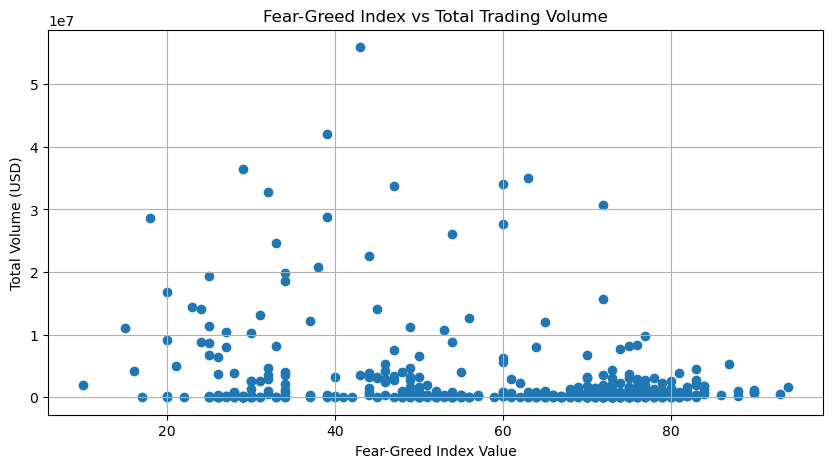

In [16]:
# (Sentiment vs Volume)
plt.figure(figsize=(10,5))
plt.scatter(merged_df["value"], merged_df["total_volume_usd"])
plt.title("Fear-Greed Index vs Total Trading Volume")
plt.xlabel("Fear-Greed Index Value")
plt.ylabel("Total Volume (USD)")
plt.grid(True)
plt.savefig("outputs/sentiment_vs_volume.png")
plt.show()

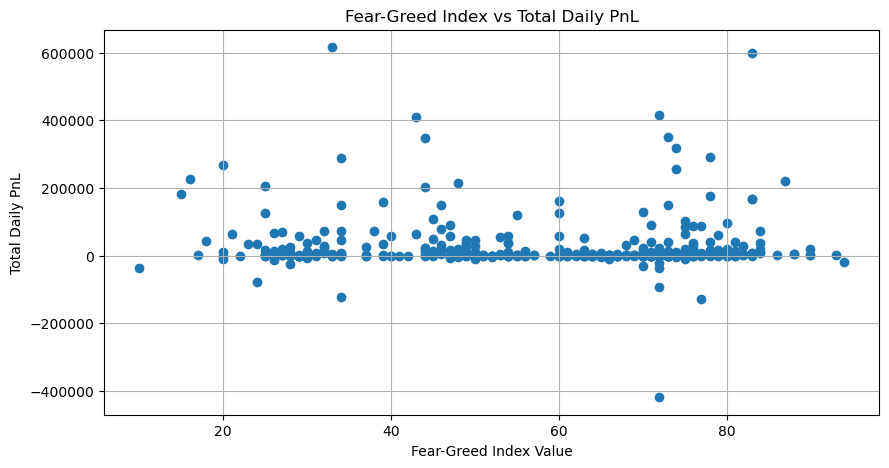

In [17]:
# (Sentiment vs PnL)
plt.figure(figsize=(10,5))
plt.scatter(merged_df["value"], merged_df["total_pnl"])
plt.title("Fear-Greed Index vs Total Daily PnL")
plt.xlabel("Fear-Greed Index Value")
plt.ylabel("Total Daily PnL")
plt.grid(True)
plt.savefig("outputs/sentiment_vs_PnL.png")
plt.show()


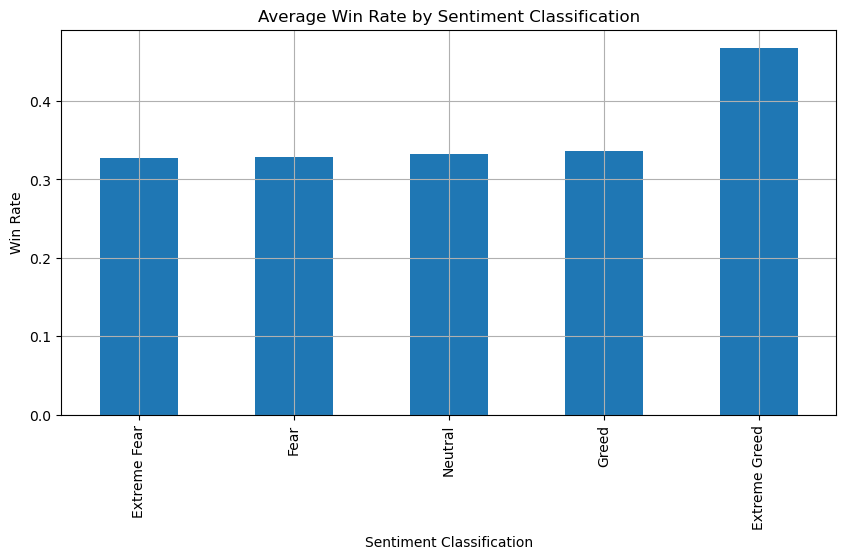

In [18]:
# (Win rate by sentiment)
class_winrate = merged_df.groupby("classification")["win_rate"].mean().sort_values()

plt.figure(figsize=(10,5))
class_winrate.plot(kind="bar")
plt.title("Average Win Rate by Sentiment Classification")
plt.xlabel("Sentiment Classification")
plt.ylabel("Win Rate")
plt.grid(True)
plt.savefig("outputs/Win rate vs sentiment.png")
plt.show()


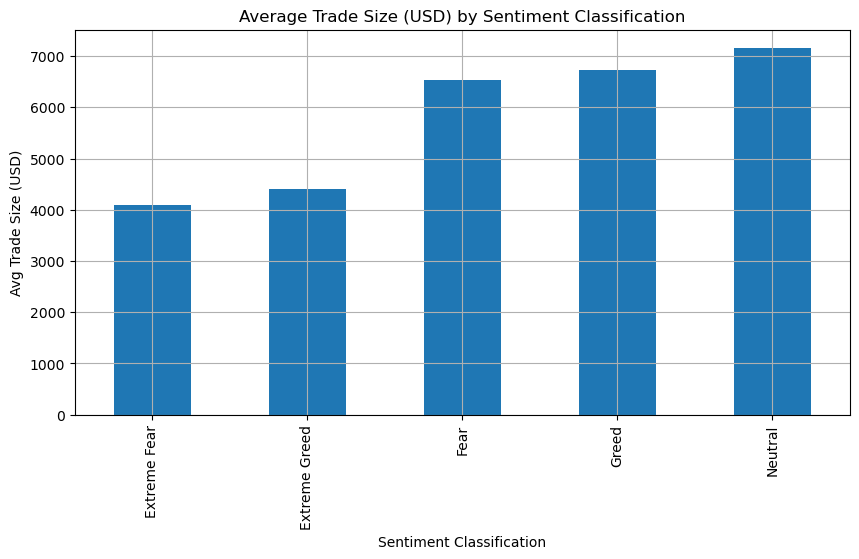

In [19]:
# Avg trade size by sentiment
avgsize_class = merged_df.groupby("classification")["avg_trade_size"].mean().sort_values()

plt.figure(figsize=(10,5))
avgsize_class.plot(kind="bar")
plt.title("Average Trade Size (USD) by Sentiment Classification")
plt.xlabel("Sentiment Classification")
plt.ylabel("Avg Trade Size (USD)")
plt.grid(True)
plt.savefig("outputs/Avg trade size vs sentiment.png")
plt.show()